In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [37]:
df = pd.read_csv("supernova_dataset.csv")

In [38]:
df.head()

,kepid,koi_disposition,koi_period,koi_duration,koi_depth,koi_impact,koi_model_snr,koi_num_transits,koi_ror,koi_prad,...,teff_err1,teff_err2,logg_err1,logg_err2,feh_err1,feh_err2,mass_err1,mass_err2,radius_err1,radius_err2
0,10797460,CONFIRMED,9.488036,2.95750,615.8,0.146,35.8,142.0,0.022344,2.26,...,123.0,-123.0,0.068,-0.243,0.15,-0.15,0.13150,-0.08685,0.465,-0.114
1,10797460,CONFIRMED,54.418383,4.50700,874.8,0.586,25.8,25.0,0.027954,2.83,...,123.0,-123.0,0.068,-0.243,0.15,-0.15,0.13150,-0.08685,0.465,-0.114
2,10811496,CANDIDATE,19.899140,1.78220,10829.0,0.969,76.3,56.0,0.154046,14.60,...,158.0,-171.0,0.044,-0.176,0.26,-0.26,0.10375,-0.11465,0.237,-0.078
3,10848459,FALSE POSITIVE,1.736952,2.40641,8079.2,1.276,505.6,621.0,0.387394,33.46,...,157.0,-144.0,0.053,-0.223,0.30,-0.26,0.09995,-0.07165,0.364,-0.068
4,10854555,CONFIRMED,2.525592,1.65450,603.3,0.701,40.9,515.0,0.024064,2.75,...,151.0,-207.0,0.070,-0.222,0.17,-0.29,0.19050,-0.13700,0.442,-0.133


In [39]:
df.sample(5)

,kepid,koi_disposition,koi_period,koi_duration,koi_depth,koi_impact,koi_model_snr,koi_num_transits,koi_ror,koi_prad,...,teff_err1,teff_err2,logg_err1,logg_err2,feh_err1,feh_err2,mass_err1,mass_err2,radius_err1,radius_err2
2032,9026749,CONFIRMED,66.557673,10.5320,214.2,0.254,21.3,22.0,0.013335,4.96,...,111.0,-111.0,0.2010,-0.201,0.15,-0.15,0.2105,-0.2241,0.6250,-0.525
5939,8332986,FALSE POSITIVE,302.388678,3.1229,41320.0,1.134,294.8,5.0,0.435247,40.73,...,106.0,-106.0,0.0660,-0.080,0.15,-0.15,0.0580,-0.0430,0.0930,-0.058
7283,11081504,CANDIDATE,9.618311,4.2150,25.0,0.447,11.9,137.0,0.004666,0.85,...,124.0,-124.0,0.1820,-0.147,0.15,-0.15,0.1600,-0.1150,0.4370,-0.367
7400,10614158,FALSE POSITIVE,4.462553,14.0957,22720.0,0.004,140.9,58.0,0.133443,52.74,...,144.0,-112.5,0.2855,-0.373,0.29,-0.21,0.3465,-0.0920,2.5375,-0.953
6681,7819520,FALSE POSITIVE,230.804016,3.5700,NaN,NaN,NaN,NaN,NaN,NaN,...,149.0,-186.0,0.0460,-0.184,0.21,-0.30,0.1095,-0.1360,0.2890,-0.100


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kepid             9564 non-null   int64  
 1   koi_disposition   9564 non-null   object 
 2   koi_period        9564 non-null   float64
 3   koi_duration      9564 non-null   float64
 4   koi_depth         9201 non-null   float64
 5   koi_impact        9201 non-null   float64
 6   koi_model_snr     9201 non-null   float64
 7   koi_num_transits  8422 non-null   float64
 8   koi_ror           9201 non-null   float64
 9   koi_prad          9201 non-null   float64
 10  st_teff           9564 non-null   float64
 11  st_logg           9564 non-null   float64
 12  st_met            9564 non-null   float64
 13  st_mass           9455 non-null   float64
 14  st_radius         9564 non-null   float64
 15  st_dens           9455 non-null   float64
 16  teff_err1         9455 non-null   float64


In [41]:
df.describe()

,kepid,koi_period,koi_duration,koi_depth,koi_impact,koi_model_snr,koi_num_transits,koi_ror,koi_prad,st_teff,...,teff_err1,teff_err2,logg_err1,logg_err2,feh_err1,feh_err2,mass_err1,mass_err2,radius_err1,radius_err2
count,9.564000e+03,9564.000000,9564.000000,9.201000e+03,9201.000000,9201.000000,8422.000000,9201.000000,9201.000000,9564.000000,...,9455.000000,9455.000000,9455.000000,9455.000000,9455.000000,9455.000000,9455.000000,9455.000000,9455.000000,9455.000000
mean,7.690628e+06,75.671358,5.621606,2.379134e+04,0.735105,259.895001,385.006768,0.283646,102.891778,5735.384097,...,143.579799,-157.755050,0.112668,-0.173389,0.216397,-0.241631,0.135913,-0.138698,0.426745,-0.352531
std,2.653459e+06,1334.744046,6.471554,8.224268e+04,3.348832,795.806615,545.756200,3.306558,3077.639126,813.065666,...,42.852680,62.775082,0.104687,0.080668,0.070713,0.077279,0.085605,0.168463,0.887806,1.701414
min,7.574500e+05,0.241843,0.052000,0.000000e+00,0.000000,0.000000,0.000000,0.001289,0.080000,2661.000000,...,0.000000,-1473.000000,0.000000,-0.748000,0.000000,-0.750000,0.000000,-2.579000,0.000000,-101.136000
25%,5.556034e+06,2.733684,2.437750,1.599000e+02,0.197000,12.000000,41.000000,0.012341,1.400000,5325.000000,...,109.000000,-190.000000,0.045000,-0.224000,0.150000,-0.300000,0.081925,-0.138000,0.196000,-0.270000
50%,7.906892e+06,9.752831,3.792600,4.211000e+02,0.537000,23.000000,143.000000,0.021076,2.390000,5783.000000,...,153.000000,-149.000000,0.074000,-0.193000,0.220000,-0.260000,0.115500,-0.098000,0.356000,-0.114000
75%,9.873066e+06,40.715178,6.276500,1.473400e+03,0.889000,78.000000,469.000000,0.095348,14.930000,6143.000000,...,168.000000,-115.000000,0.153000,-0.122000,0.280000,-0.150000,0.177500,-0.064000,0.453000,-0.071000
max,1.293514e+07,129995.778400,138.540000,1.541400e+06,100.806000,9054.700000,2664.000000,99.870651,200346.000000,15896.000000,...,676.000000,0.000000,1.184000,0.000000,0.450000,0.000000,1.493000,0.000000,25.956000,0.000000


In [42]:
df.shape

(9564, 26)

In [43]:
df.columns

Index(['kepid', 'koi_disposition', 'koi_period', 'koi_duration', 'koi_depth',
       'koi_impact', 'koi_model_snr', 'koi_num_transits', 'koi_ror',
       'koi_prad', 'st_teff', 'st_logg', 'st_met', 'st_mass', 'st_radius',
       'st_dens', 'teff_err1', 'teff_err2', 'logg_err1', 'logg_err2',
       'feh_err1', 'feh_err2', 'mass_err1', 'mass_err2', 'radius_err1',
       'radius_err2'],
      dtype='object')

In [44]:
df[df['koi_prad'].isnull()]['koi_disposition'].value_counts()

koi_disposition
FALSE POSITIVE    257
CANDIDATE         104
CONFIRMED           2
Name: count, dtype: int64

In [45]:
clf_df = df[df['koi_disposition'].isin(['CONFIRMED', 'FALSE POSITIVE'])].copy()

In [46]:
clf_df.describe()

,kepid,koi_period,koi_duration,koi_depth,koi_impact,koi_model_snr,koi_num_transits,koi_ror,koi_prad,st_teff,...,teff_err1,teff_err2,logg_err1,logg_err2,feh_err1,feh_err2,mass_err1,mass_err2,radius_err1,radius_err2
count,7.585000e+03,7585.000000,7585.000000,7.326000e+03,7326.000000,7326.000000,6904.000000,7326.000000,7326.000000,7585.000000,...,7482.000000,7482.000000,7482.000000,7482.000000,7482.000000,7482.000000,7482.000000,7482.000000,7482.000000,7482.000000
mean,7.639045e+06,51.660971,5.713065,2.952962e+04,0.756127,318.594049,419.015353,0.293333,104.169379,5741.724786,...,144.978883,-159.589548,0.112568,-0.172461,0.217788,-0.243611,0.136293,-0.138554,0.433910,-0.363159
std,2.638229e+06,111.838381,6.826210,9.117010e+04,3.196379,881.096351,568.780061,3.155387,3180.483497,835.312870,...,43.116956,64.452611,0.105240,0.081125,0.070970,0.078242,0.089269,0.171198,0.969856,1.846508
min,7.574500e+05,0.241843,0.104600,8.000000e-01,0.000000,0.000000,0.000000,0.001289,0.080000,2661.000000,...,0.000000,-1473.000000,0.000000,-0.748000,0.000000,-0.750000,0.000000,-2.579000,0.000000,-101.136000
25%,5.513893e+06,2.243041,2.474300,1.826500e+02,0.227000,15.400000,46.000000,0.013230,1.500000,5327.000000,...,110.000000,-192.000000,0.044000,-0.224000,0.150000,-0.300000,0.081000,-0.138000,0.190000,-0.266000
50%,7.832356e+06,8.073941,3.836000,5.015000e+02,0.586000,30.500000,164.000000,0.023843,2.620000,5783.000000,...,154.000000,-151.000000,0.073750,-0.192500,0.220000,-0.260000,0.115175,-0.098000,0.355000,-0.113000
75%,9.837661e+06,30.552897,6.271000,2.319050e+03,0.917000,114.775000,549.000000,0.197202,24.185000,6140.000000,...,169.000000,-117.000000,0.153000,-0.120625,0.280000,-0.150000,0.177000,-0.063000,0.451000,-0.070000
max,1.293514e+07,1071.232624,138.540000,1.541400e+06,100.806000,9054.700000,2664.000000,99.870651,200346.000000,15896.000000,...,676.000000,0.000000,1.184000,0.000000,0.450000,0.000000,1.493000,0.000000,25.956000,0.000000


In [47]:
reg_df = df[
    (df['koi_disposition'] == 'CONFIRMED') &
    (df['koi_prad'].notnull())
].copy()

In [48]:
df['koi_disposition'].value_counts()

koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2746
CANDIDATE         1979
Name: count, dtype: int64

C:\Users\Suraj\AppData\Local\Temp\ipykernel_29596\1679544966.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=45, horizontalalignment='right')


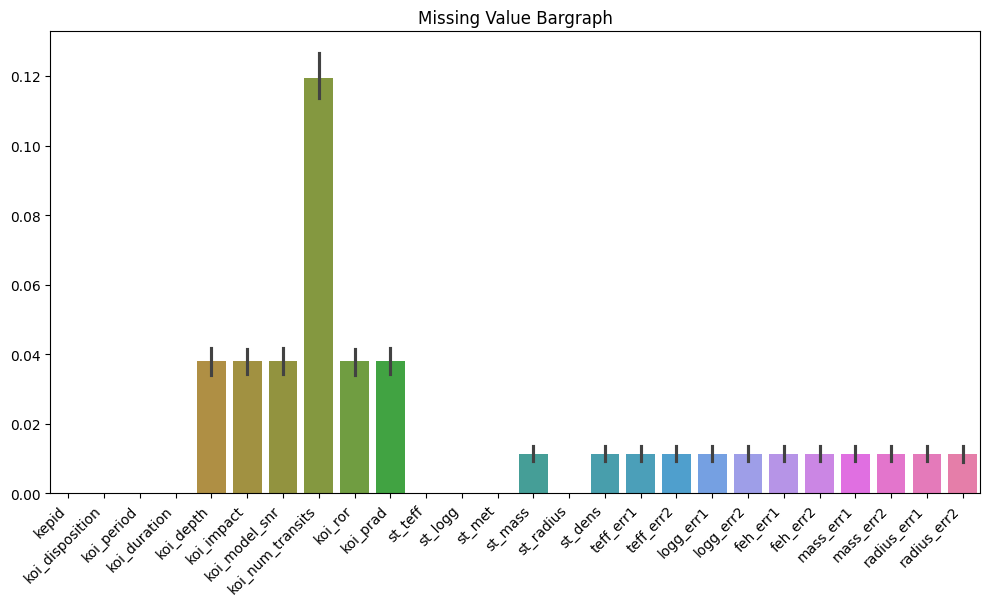

In [49]:
plt.figure(figsize=(12,6))
plot = sns.barplot(df.isnull())
plot.set_xticklabels(plot.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.title("Missing Value Bargraph")
plt.show()

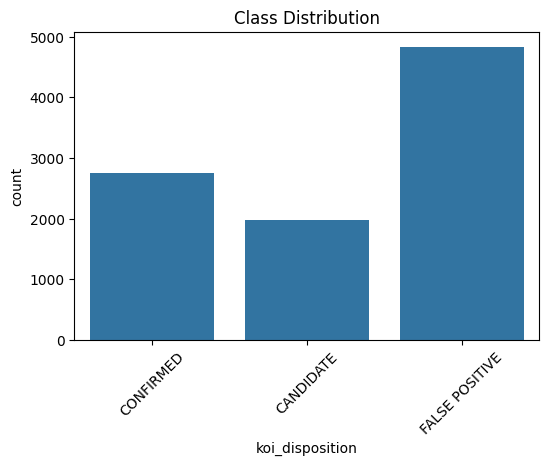

In [50]:
plt.figure(figsize=(6,4))
sns.countplot(x='koi_disposition', data=df)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

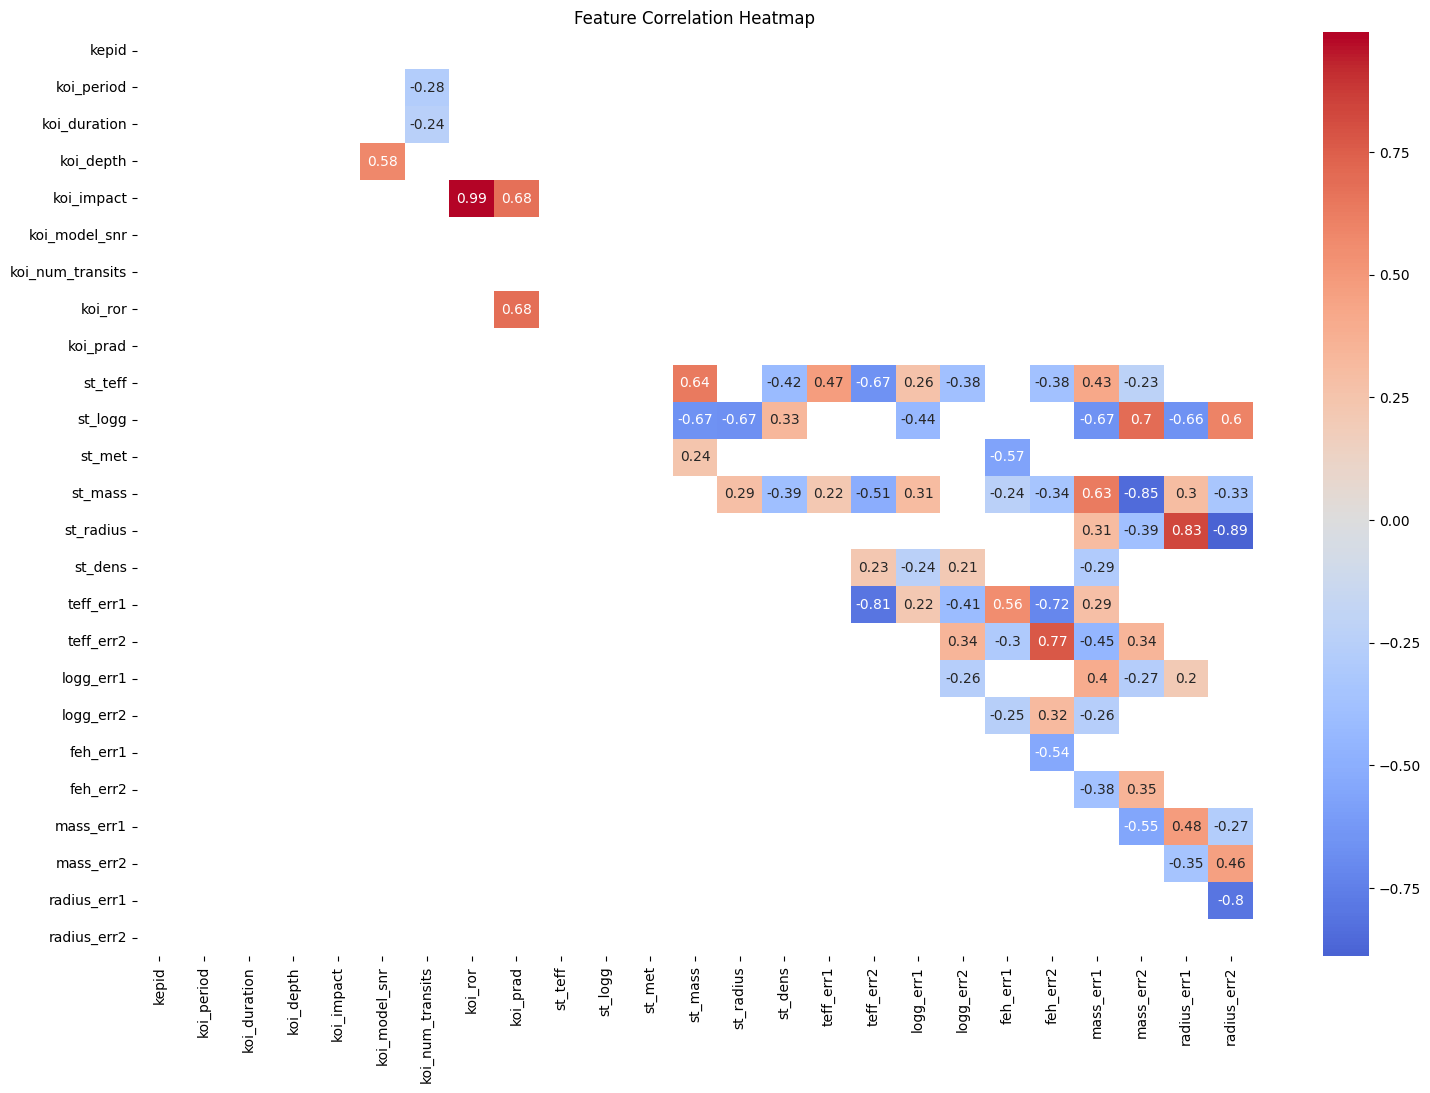

In [51]:
plt.figure(figsize=(18,12))
corr = df.corr(numeric_only=True)
threshold = 0.2
mask1 = abs(corr) < threshold
mask2 = np.tril(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, cmap='coolwarm', mask= mask1 | mask2 ,center=0, annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

C:\Users\Suraj\AppData\Local\Temp\ipykernel_29596\1483109878.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=45, horizontalalignment='right')


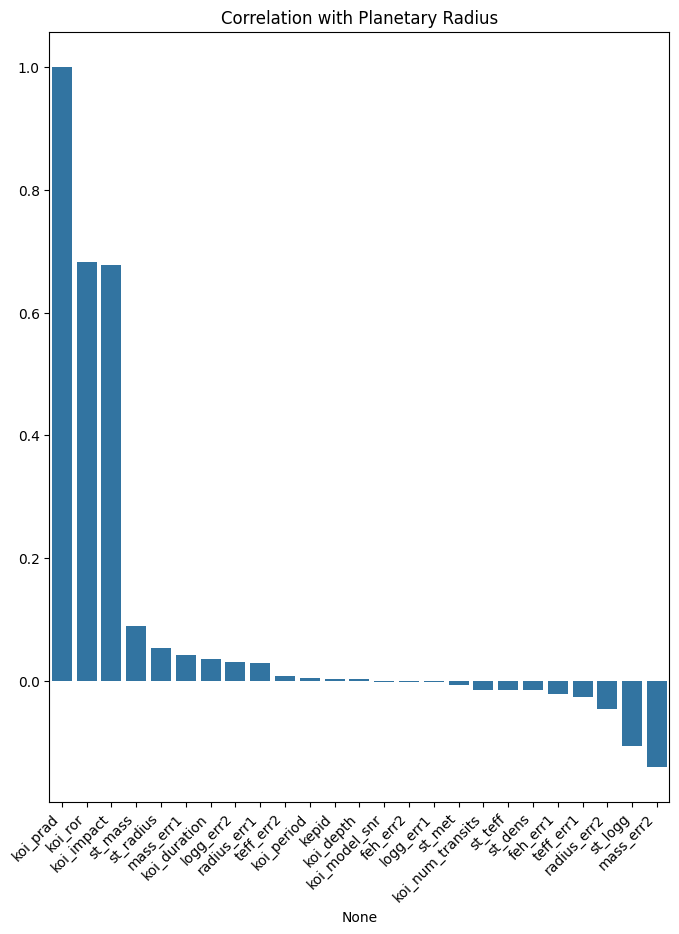

In [52]:
corr_target = corr['koi_prad'].sort_values(ascending=False)

plt.figure(figsize=(8,10))
plot = sns.barplot(y=corr_target.values, x=corr_target.index)
plot.set_xticklabels(plot.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.title("Correlation with Planetary Radius")
plt.show()

In [53]:
df['koi_prad'].skew()

np.float64(52.11895420603228)

In [54]:
reg_df['koi_prad'] = np.log1p(reg_df['koi_prad'])

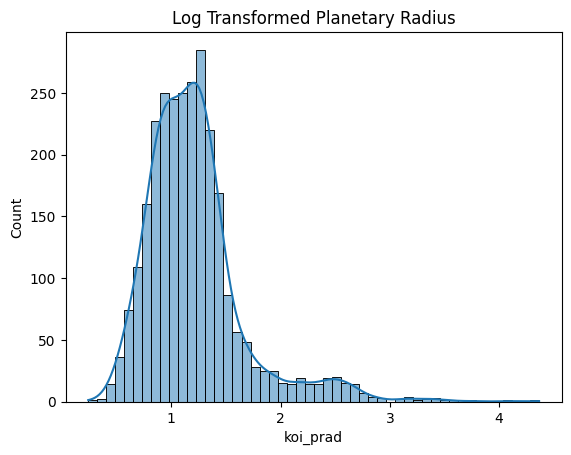

1.7759471005160161


In [55]:
sns.histplot(reg_df['koi_prad'], bins=50, kde=True)
plt.title("Log Transformed Planetary Radius")
plt.show()

print(reg_df['koi_prad'].skew())

In [56]:
from sklearn.model_selection import train_test_split

clf_df = df[df['koi_disposition'].isin(['CONFIRMED', 'FALSE POSITIVE'])].copy()

clf_df['target'] = clf_df['koi_disposition'].map({
    'CONFIRMED': 1,
    'FALSE POSITIVE': 0
})

X_clf = clf_df.drop(columns=['kepid', 'koi_disposition', 'koi_prad', 'target'])
y_clf = clf_df['target']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    stratify=y_clf,
    random_state=42
)

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

clf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
])

clf_pipeline.fit(X_train_clf, y_train_clf)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [58]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = clf_pipeline.predict(X_test_clf)
y_proba = clf_pipeline.predict_proba(X_test_clf)[:,1]

print(classification_report(y_test_clf, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_clf, y_proba))

              precision    recall  f1-score   support

           0       0.93      0.86      0.90       968
           1       0.79      0.89      0.83       549

    accuracy                           0.87      1517
   macro avg       0.86      0.87      0.86      1517
weighted avg       0.88      0.87      0.87      1517

ROC-AUC: 0.9436955245450029


In [59]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight='balanced',
        random_state=42
    ))
])

rf_pipeline.fit(X_train_clf, y_train_clf)

y_pred_rf = rf_pipeline.predict(X_test_clf)
y_proba_rf = rf_pipeline.predict_proba(X_test_clf)[:,1]

print(classification_report(y_test_clf, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test_clf, y_proba_rf))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       968
           1       0.93      0.87      0.90       549

    accuracy                           0.93      1517
   macro avg       0.93      0.92      0.92      1517
weighted avg       0.93      0.93      0.93      1517

ROC-AUC: 0.9813513299914194


----

In [60]:
# from sklearn.model_selection import GroupShuffleSplit

In [61]:
# groups = clf_df['kepid']

In [62]:
# gss = GroupShuffleSplit(
#     n_splits=1,
#     test_size=0.2,
#     random_state=42
# )

# train_idx, test_idx = next(gss.split(X_clf, y_clf, groups=groups))

# X_train_clf = X_clf.iloc[train_idx]
# X_test_clf  = X_clf.iloc[test_idx]
# y_train_clf = y_clf.iloc[train_idx]
# y_test_clf  = y_clf.iloc[test_idx]

In [63]:
# train_kepids = set(groups.iloc[train_idx])
# test_kepids = set(groups.iloc[test_idx])

# print("Star overlap:", len(train_kepids.intersection(test_kepids)))

In [64]:
# clf_pipeline.fit(X_train_clf, y_train_clf)
# y_pred = clf_pipeline.predict(X_test_clf)
# y_proba = clf_pipeline.predict_proba(X_test_clf)[:,1]

In [65]:
# from sklearn.metrics import classification_report, roc_auc_score

# print(classification_report(y_test_clf, y_pred))
# print("ROC-AUC:", roc_auc_score(y_test_clf, y_proba))

In [66]:
# from sklearn.model_selection import GroupKFold
# from sklearn.metrics import roc_auc_score
# import numpy as np

# gkf = GroupKFold(n_splits=5)
# groups = clf_df['kepid']

# roc_scores = []

# for train_idx, test_idx in gkf.split(X_clf, y_clf, groups):
#     X_train, X_test = X_clf.iloc[train_idx], X_clf.iloc[test_idx]
#     y_train, y_test = y_clf.iloc[train_idx], y_clf.iloc[test_idx]

#     rf_pipeline.fit(X_train, y_train)
#     y_proba = rf_pipeline.predict_proba(X_test)[:,1]
#     roc_scores.append(roc_auc_score(y_test, y_proba))

# print("Mean ROC-AUC:", np.mean(roc_scores))
# print("Std ROC-AUC:", np.std(roc_scores))

------

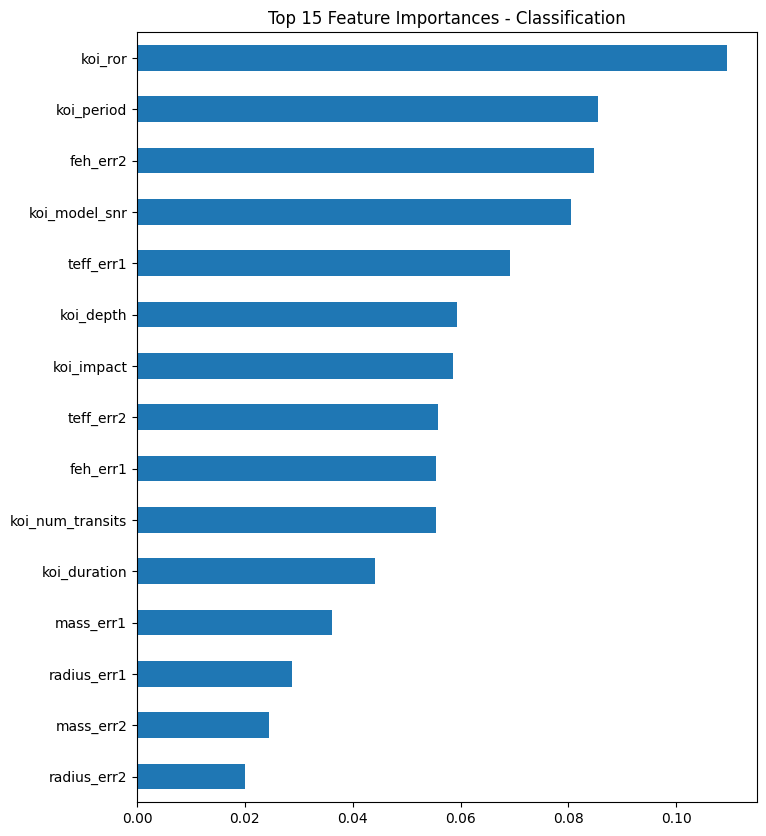

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_pipeline.named_steps['model'].feature_importances_
features = X_train_clf.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,10))
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Classification")
plt.show()

In [68]:
print(feat_imp)

koi_ror             0.109471
koi_period          0.085451
feh_err2            0.084791
koi_model_snr       0.080418
teff_err1           0.069139
koi_depth           0.059245
koi_impact          0.058551
teff_err2           0.055741
feh_err1            0.055364
koi_num_transits    0.055360
koi_duration        0.044220
mass_err1           0.036204
radius_err1         0.028668
mass_err2           0.024469
radius_err2         0.020116
st_dens             0.019560
st_radius           0.019553
st_logg             0.019204
st_met              0.016639
st_teff             0.016153
st_mass             0.015056
logg_err2           0.014261
logg_err1           0.012365
dtype: float64


In [69]:
reg_df = df[
    (df['koi_disposition'] == 'CONFIRMED') &
    (df['koi_prad'].notnull())
].copy()

reg_df = reg_df.drop(columns=['kepid', 'koi_disposition'])

In [70]:
import numpy as np

reg_df['koi_prad'] = np.log1p(reg_df['koi_prad'])

In [71]:
X_reg = reg_df.drop(columns=['koi_prad'])
y_reg = reg_df['koi_prad']

In [72]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

In [73]:
from xgboost import XGBRegressor

In [74]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

reg_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

reg_pipeline.fit(X_train_reg, y_train_reg)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

In [75]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_pred_log = reg_pipeline.predict(X_test_reg)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test_reg)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 1.0916786654931665
MAE: 0.19508776584826754


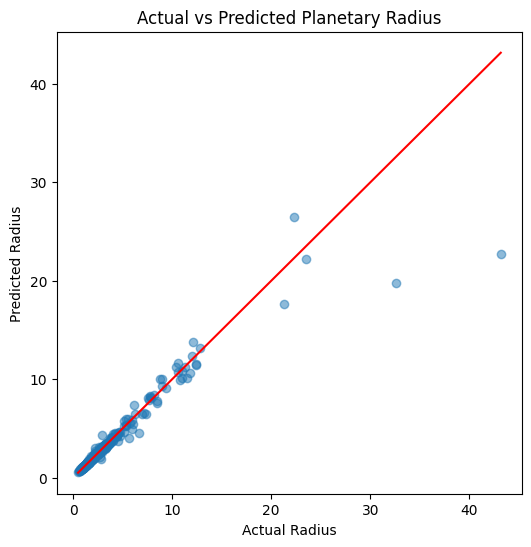

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.xlabel("Actual Radius")
plt.ylabel("Predicted Radius")
plt.title("Actual vs Predicted Planetary Radius")
plt.plot([min(y_true), max(y_true)],
         [min(y_true), max(y_true)],
         color='red')
plt.show()

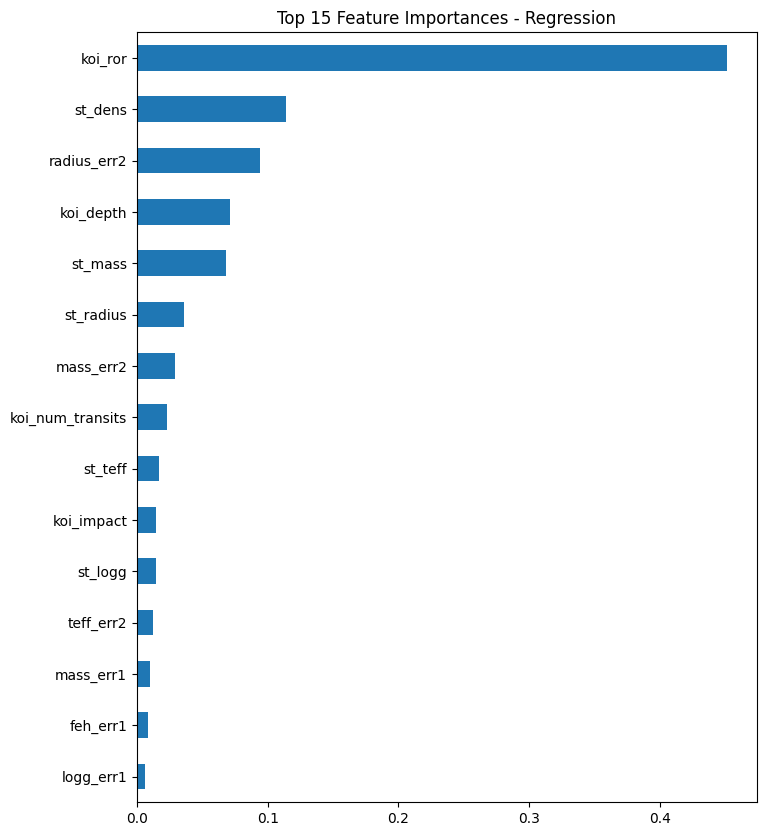

In [77]:
importances_reg = reg_pipeline.named_steps['model'].feature_importances_
features_reg = X_train_reg.columns

feat_imp_reg = pd.Series(importances_reg, index=features_reg).sort_values(ascending=False)

plt.figure(figsize=(8,10))
feat_imp_reg.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Regression")
plt.show()

In [78]:
print(feat_imp_reg)

koi_ror             0.451717
st_dens             0.114201
radius_err2         0.094082
koi_depth           0.071268
st_mass             0.068041
st_radius           0.036137
mass_err2           0.028976
koi_num_transits    0.022790
st_teff             0.016686
koi_impact          0.014744
st_logg             0.014529
teff_err2           0.011992
mass_err1           0.010073
feh_err1            0.008511
logg_err1           0.006323
radius_err1         0.005898
teff_err1           0.005859
koi_model_snr       0.004331
st_met              0.004182
feh_err2            0.003434
logg_err2           0.003085
koi_duration        0.001870
koi_period          0.001270
dtype: float32


In [79]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_pipeline,
    X_clf,
    y_clf,
    cv=5,
    scoring='roc_auc'
)

print("CV ROC-AUC:", cv_scores)
print("Mean:", cv_scores.mean())

CV ROC-AUC: [0.95906741 0.98664552 0.96248815 0.99546791 0.96559485]
Mean: 0.9738527637869749


In [80]:
cv_rmse = -cross_val_score(
    reg_pipeline,
    X_reg,
    y_reg,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

print(cv_rmse)
print("Mean RMSE (log space):", cv_rmse.mean())

[0.1040649  0.06480604 0.07203569 0.05573185 0.11988765]
Mean RMSE (log space): 0.08330522670023784


In [81]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    rf_pipeline,
    X_test_clf,
    y_test_clf,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

perm_df = pd.Series(
    perm_importance.importances_mean,
    index=X_test_clf.columns
).sort_values(ascending=False)

print(perm_df.head(10))

koi_ror             0.047315
koi_model_snr       0.017637
koi_period          0.015124
koi_duration        0.012293
koi_impact          0.012085
koi_depth           0.006660
koi_num_transits    0.006642
feh_err2            0.006164
feh_err1            0.002470
mass_err1           0.001869
dtype: float64


In [83]:
import joblib

joblib.dump(rf_pipeline, "classification_model.pkl")
joblib.dump(reg_pipeline, "regression_model.pkl")

['regression_model.pkl']

In [85]:
X_reg_no_ror = X_reg.drop(columns=['koi_ror'])

X_train_nr, X_test_nr, y_train_nr, y_test_nr = train_test_split(
    X_reg_no_ror,
    y_reg,
    test_size=0.2,
    random_state=42
)

reg_pipeline_nr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBRegressor(n_estimators=400, random_state=42))
])

reg_pipeline_nr.fit(X_train_nr, y_train_nr)

y_pred_log_nr = reg_pipeline_nr.predict(X_test_nr)

y_pred_nr = np.expm1(y_pred_log_nr)
y_true_nr = np.expm1(y_test_nr)

rmse_nr = np.sqrt(mean_squared_error(y_true_nr, y_pred_nr))
mae_nr = mean_absolute_error(y_true_nr, y_pred_nr)

print("RMSE without koi_ror:", rmse_nr)
print("MAE without koi_ror:", mae_nr)

RMSE without koi_ror: 1.6591283768301428
MAE without koi_ror: 0.314474438769787


RMSE: 1.0916786654931665
MAE: 0.19508776584826754

In [86]:
import joblib

model = joblib.load("classification_model.pkl")
print(model.feature_names_in_)

['koi_period' 'koi_duration' 'koi_depth' 'koi_impact' 'koi_model_snr'
 'koi_num_transits' 'koi_ror' 'st_teff' 'st_logg' 'st_met' 'st_mass'
 'st_radius' 'st_dens' 'teff_err1' 'teff_err2' 'logg_err1' 'logg_err2'
 'feh_err1' 'feh_err2' 'mass_err1' 'mass_err2' 'radius_err1' 'radius_err2']
